In [38]:
import pandas as pd
import numpy as np
from scipy.stats import norm

df = pd.read_csv("data/sp500_data_from_2010.csv", parse_dates=["Date"])

df

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2010-01-04,A,22.453505,22.625179,22.267525,22.389128,19.891682,3815561.0
1,2010-01-04,AAPL,7.622500,7.660714,7.585000,7.643214,6.418382,493729600.0
2,2010-01-04,ABT,26.000362,26.177889,25.870815,26.129908,18.414783,10829095.0
3,2010-01-04,ACGL,7.978889,8.022222,7.972222,7.994444,7.601905,4813200.0
4,2010-01-04,ACN,41.520000,42.200001,41.500000,42.070000,31.492174,3650100.0
...,...,...,...,...,...,...,...,...
1689654,2025-12-30,XEL,73.989998,74.430000,73.989998,74.190002,74.190002,5420800.0
1689655,2025-12-30,XOM,121.099998,121.800003,120.629997,120.989998,120.989998,11148100.0
1689656,2025-12-30,YUM,151.679993,152.660004,151.449997,152.179993,152.179993,1158600.0
1689657,2025-12-30,ZBH,90.180000,90.919998,89.879997,90.790001,90.790001,934500.0


In [39]:
# artihmetic returns
df = df.sort_values(["Ticker", "Date"])

df["previous_adj_close"] = (
    df.groupby("Ticker")["Adj Close"]
      .shift(1)
)


df["arithmetic_return"] = (
    ( df["Adj Close"] - df["previous_adj_close"] ) / df["previous_adj_close"]
)

# remove first observation per ticker
df= df.dropna(subset=["arithmetic_return"])

display(df)

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return
420,2010-01-05,A,22.324751,22.331903,22.002861,22.145924,19.675604,4186031.0,19.891682,-0.010863
840,2010-01-06,A,22.067240,22.174536,22.002861,22.067240,19.605696,3243779.0,19.675604,-0.003553
1260,2010-01-07,A,22.017166,22.045780,21.816881,22.038628,19.580273,3095172.0,19.605696,-0.001297
1680,2010-01-08,A,21.917025,22.067240,21.745352,22.031473,19.573917,3733918.0,19.580273,-0.000325
2100,2010-01-11,A,22.088697,22.210300,21.938484,22.045780,19.586626,4781579.0,19.573917,0.000649
...,...,...,...,...,...,...,...,...,...,...
1687978,2025-12-23,ZBRA,248.119995,250.550003,245.470001,246.759995,246.759995,526000.0,249.380005,-0.010506
1688398,2025-12-24,ZBRA,247.669998,247.669998,244.440002,245.899994,245.899994,374200.0,246.759995,-0.003485
1688818,2025-12-26,ZBRA,245.899994,246.550003,243.690002,246.270004,246.270004,622400.0,245.899994,0.001505
1689238,2025-12-29,ZBRA,246.070007,247.250000,241.800003,245.740005,245.740005,563900.0,246.270004,-0.002152


In [40]:
# arithmetic returns in pourcent

df["arithmetic_return_%"] = df["arithmetic_return"] * 100

display(df)

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%
420,2010-01-05,A,22.324751,22.331903,22.002861,22.145924,19.675604,4186031.0,19.891682,-0.010863,-1.086272
840,2010-01-06,A,22.067240,22.174536,22.002861,22.067240,19.605696,3243779.0,19.675604,-0.003553,-0.355304
1260,2010-01-07,A,22.017166,22.045780,21.816881,22.038628,19.580273,3095172.0,19.605696,-0.001297,-0.129672
1680,2010-01-08,A,21.917025,22.067240,21.745352,22.031473,19.573917,3733918.0,19.580273,-0.000325,-0.032458
2100,2010-01-11,A,22.088697,22.210300,21.938484,22.045780,19.586626,4781579.0,19.573917,0.000649,0.064927
...,...,...,...,...,...,...,...,...,...,...,...
1687978,2025-12-23,ZBRA,248.119995,250.550003,245.470001,246.759995,246.759995,526000.0,249.380005,-0.010506,-1.050610
1688398,2025-12-24,ZBRA,247.669998,247.669998,244.440002,245.899994,245.899994,374200.0,246.759995,-0.003485,-0.348517
1688818,2025-12-26,ZBRA,245.899994,246.550003,243.690002,246.270004,246.270004,622400.0,245.899994,0.001505,0.150472
1689238,2025-12-29,ZBRA,246.070007,247.250000,241.800003,245.740005,245.740005,563900.0,246.270004,-0.002152,-0.215210


In [41]:
# Log returns
df = df.sort_values(["Ticker", "Date"])

df["log_return"] = (
    np.log(df["Adj Close"])
    - np.log(df["previous_adj_close"])
)

# remove first observation per ticker
df= df.dropna(subset=["log_return"])

display(df)

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return
420,2010-01-05,A,22.324751,22.331903,22.002861,22.145924,19.675604,4186031.0,19.891682,-0.010863,-1.086272,-0.010922
840,2010-01-06,A,22.067240,22.174536,22.002861,22.067240,19.605696,3243779.0,19.675604,-0.003553,-0.355304,-0.003559
1260,2010-01-07,A,22.017166,22.045780,21.816881,22.038628,19.580273,3095172.0,19.605696,-0.001297,-0.129672,-0.001298
1680,2010-01-08,A,21.917025,22.067240,21.745352,22.031473,19.573917,3733918.0,19.580273,-0.000325,-0.032458,-0.000325
2100,2010-01-11,A,22.088697,22.210300,21.938484,22.045780,19.586626,4781579.0,19.573917,0.000649,0.064927,0.000649
...,...,...,...,...,...,...,...,...,...,...,...,...
1687978,2025-12-23,ZBRA,248.119995,250.550003,245.470001,246.759995,246.759995,526000.0,249.380005,-0.010506,-1.050610,-0.010562
1688398,2025-12-24,ZBRA,247.669998,247.669998,244.440002,245.899994,245.899994,374200.0,246.759995,-0.003485,-0.348517,-0.003491
1688818,2025-12-26,ZBRA,245.899994,246.550003,243.690002,246.270004,246.270004,622400.0,245.899994,0.001505,0.150472,0.001504
1689238,2025-12-29,ZBRA,246.070007,247.250000,241.800003,245.740005,245.740005,563900.0,246.270004,-0.002152,-0.215210,-0.002154


In [42]:
ari_r = df["arithmetic_return"]

stats_summary = pd.Series({
    "count": ari_r.count(),
    "mean": ari_r.mean(),
    "std": ari_r.std(),
    "variance": ari_r.var(),
    "min": ari_r.min(),
    "1%": ari_r.quantile(0.01),
    "5%": ari_r.quantile(0.05),
    "25%": ari_r.quantile(0.25),
    "median": ari_r.median(),
    "75%": ari_r.quantile(0.75),
    "95%": ari_r.quantile(0.95),
    "99%": ari_r.quantile(0.99),
    "max": ari_r.max(),
    "skewness": ari_r.skew(),
    "kurtosis": ari_r.kurt()
})

stats_summary.apply(lambda x: f"{x:.6f}")

count       1689239.000000
mean              0.000689
std               0.019217
variance          0.000369
min              -0.538647
1%               -0.051715
5%               -0.027140
25%              -0.007857
median            0.000743
75%               0.009348
95%               0.027817
99%               0.053147
max               0.745933
skewness          0.140330
kurtosis         23.992342
dtype: object

In [43]:
log_r = df["log_return"]

stats_summary = pd.Series({
    "count": log_r.count(),
    "mean": log_r.mean(),
    "std": log_r.std(),
    "variance": log_r.var(),
    "min": log_r.min(),
    "1%": log_r.quantile(0.01),
    "5%": log_r.quantile(0.05),
    "25%": log_r.quantile(0.25),
    "median": log_r.median(),
    "75%": log_r.quantile(0.75),
    "95%": log_r.quantile(0.95),
    "99%": log_r.quantile(0.99),
    "max": log_r.max(),
    "skewness": log_r.skew(),
    "kurtosis": log_r.kurt()
})

stats_summary.apply(lambda x: f"{x:.6f}")


count       1689239.000000
mean              0.000504
std               0.019267
variance          0.000371
min              -0.773593
1%               -0.053100
5%               -0.027515
25%              -0.007888
median            0.000743
75%               0.009305
95%               0.027437
99%               0.051783
max               0.557289
skewness         -0.641011
kurtosis         28.409242
dtype: object

From these stats we see that the mean and median are really close to 0. The mean being slightly lower would indicate a slight left skew, confirmed by the skewness number.
THe standard deviation is about 1.9%. Which seems ok for daily equity volatility.
The minimum and maximum are really extreem compared to this volatility. Would that indicate "Fat Tails"?
The kurtosis is really high ( largely above 3 ) which indicates that this is a leptokurtic distribution. Which would also indicate "Fat Tails"?

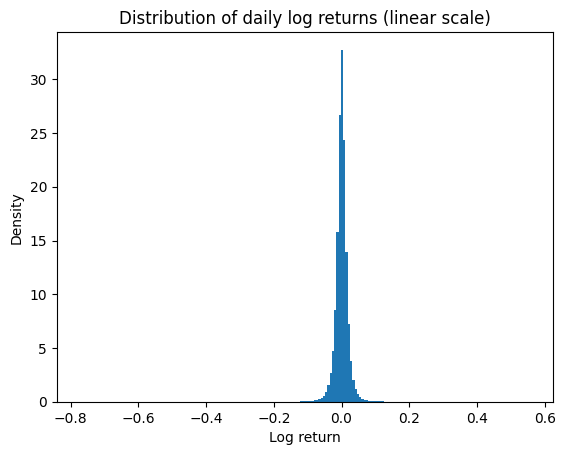

In [44]:
import matplotlib.pyplot as plt

returns = df["log_return"]

plt.hist(returns, bins=200, density=True)
plt.xlabel("Log return")
plt.ylabel("Density")
plt.title("Distribution of daily log returns (linear scale)")
plt.show()


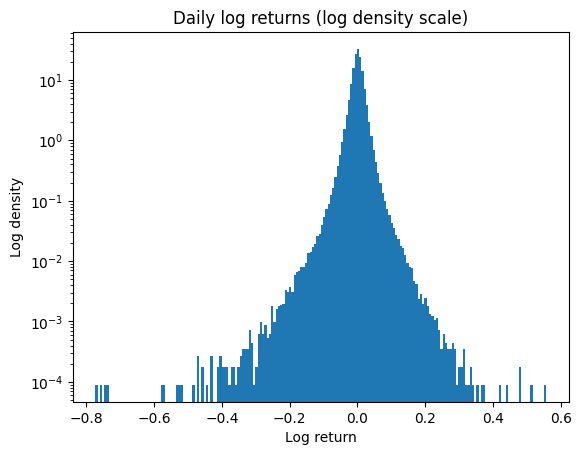

In [45]:
plt.hist(returns, bins=200, density=True)
plt.yscale("log")
plt.xlabel("Log return")
plt.ylabel("Log density")
plt.title("Daily log returns (log density scale)")
plt.show()


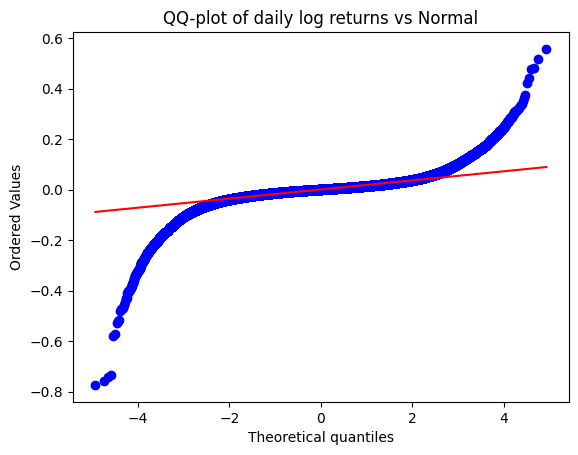

In [46]:
import scipy.stats as stats

stats.probplot(returns, dist="norm", plot=plt)
plt.title("QQ-plot of daily log returns vs Normal")
plt.show()


We overlay with a normal to see how it fits

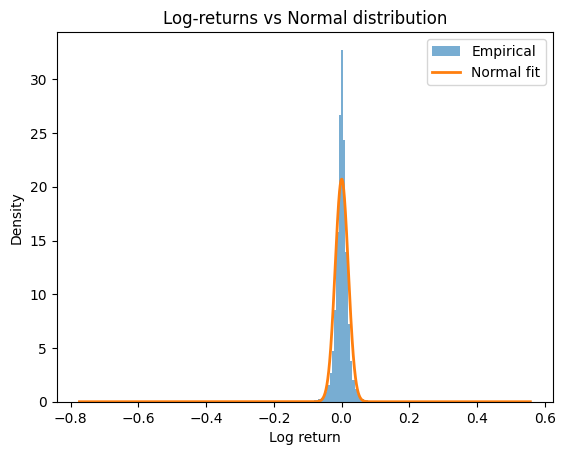

In [47]:
returns = df["log_return"].dropna()

mu = returns.mean()
sigma = returns.std()

x = np.linspace(returns.min(), returns.max(), 2000)

plt.hist(returns, bins=200, density=True, alpha=0.6, label="Empirical")
plt.plot(x, norm.pdf(x, mu, sigma), lw=2, label="Normal fit")

plt.xlabel("Log return")
plt.ylabel("Density")
plt.title("Log-returns vs Normal distribution")
plt.legend()
plt.show()

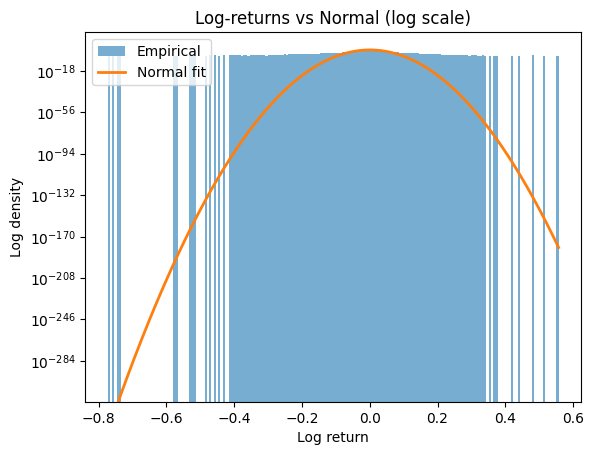

In [48]:

plt.hist(returns, bins=200, density=True, alpha=0.6, label="Empirical")
plt.plot(x, norm.pdf(x, mu, sigma), lw=2, label="Normal fit")

plt.yscale("log")
plt.xlabel("Log return")
plt.ylabel("Log density")
plt.title("Log-returns vs Normal (log scale)")
plt.legend()
plt.show()

My visualization fails because the normal is going way down in really low values... And the log scale follows

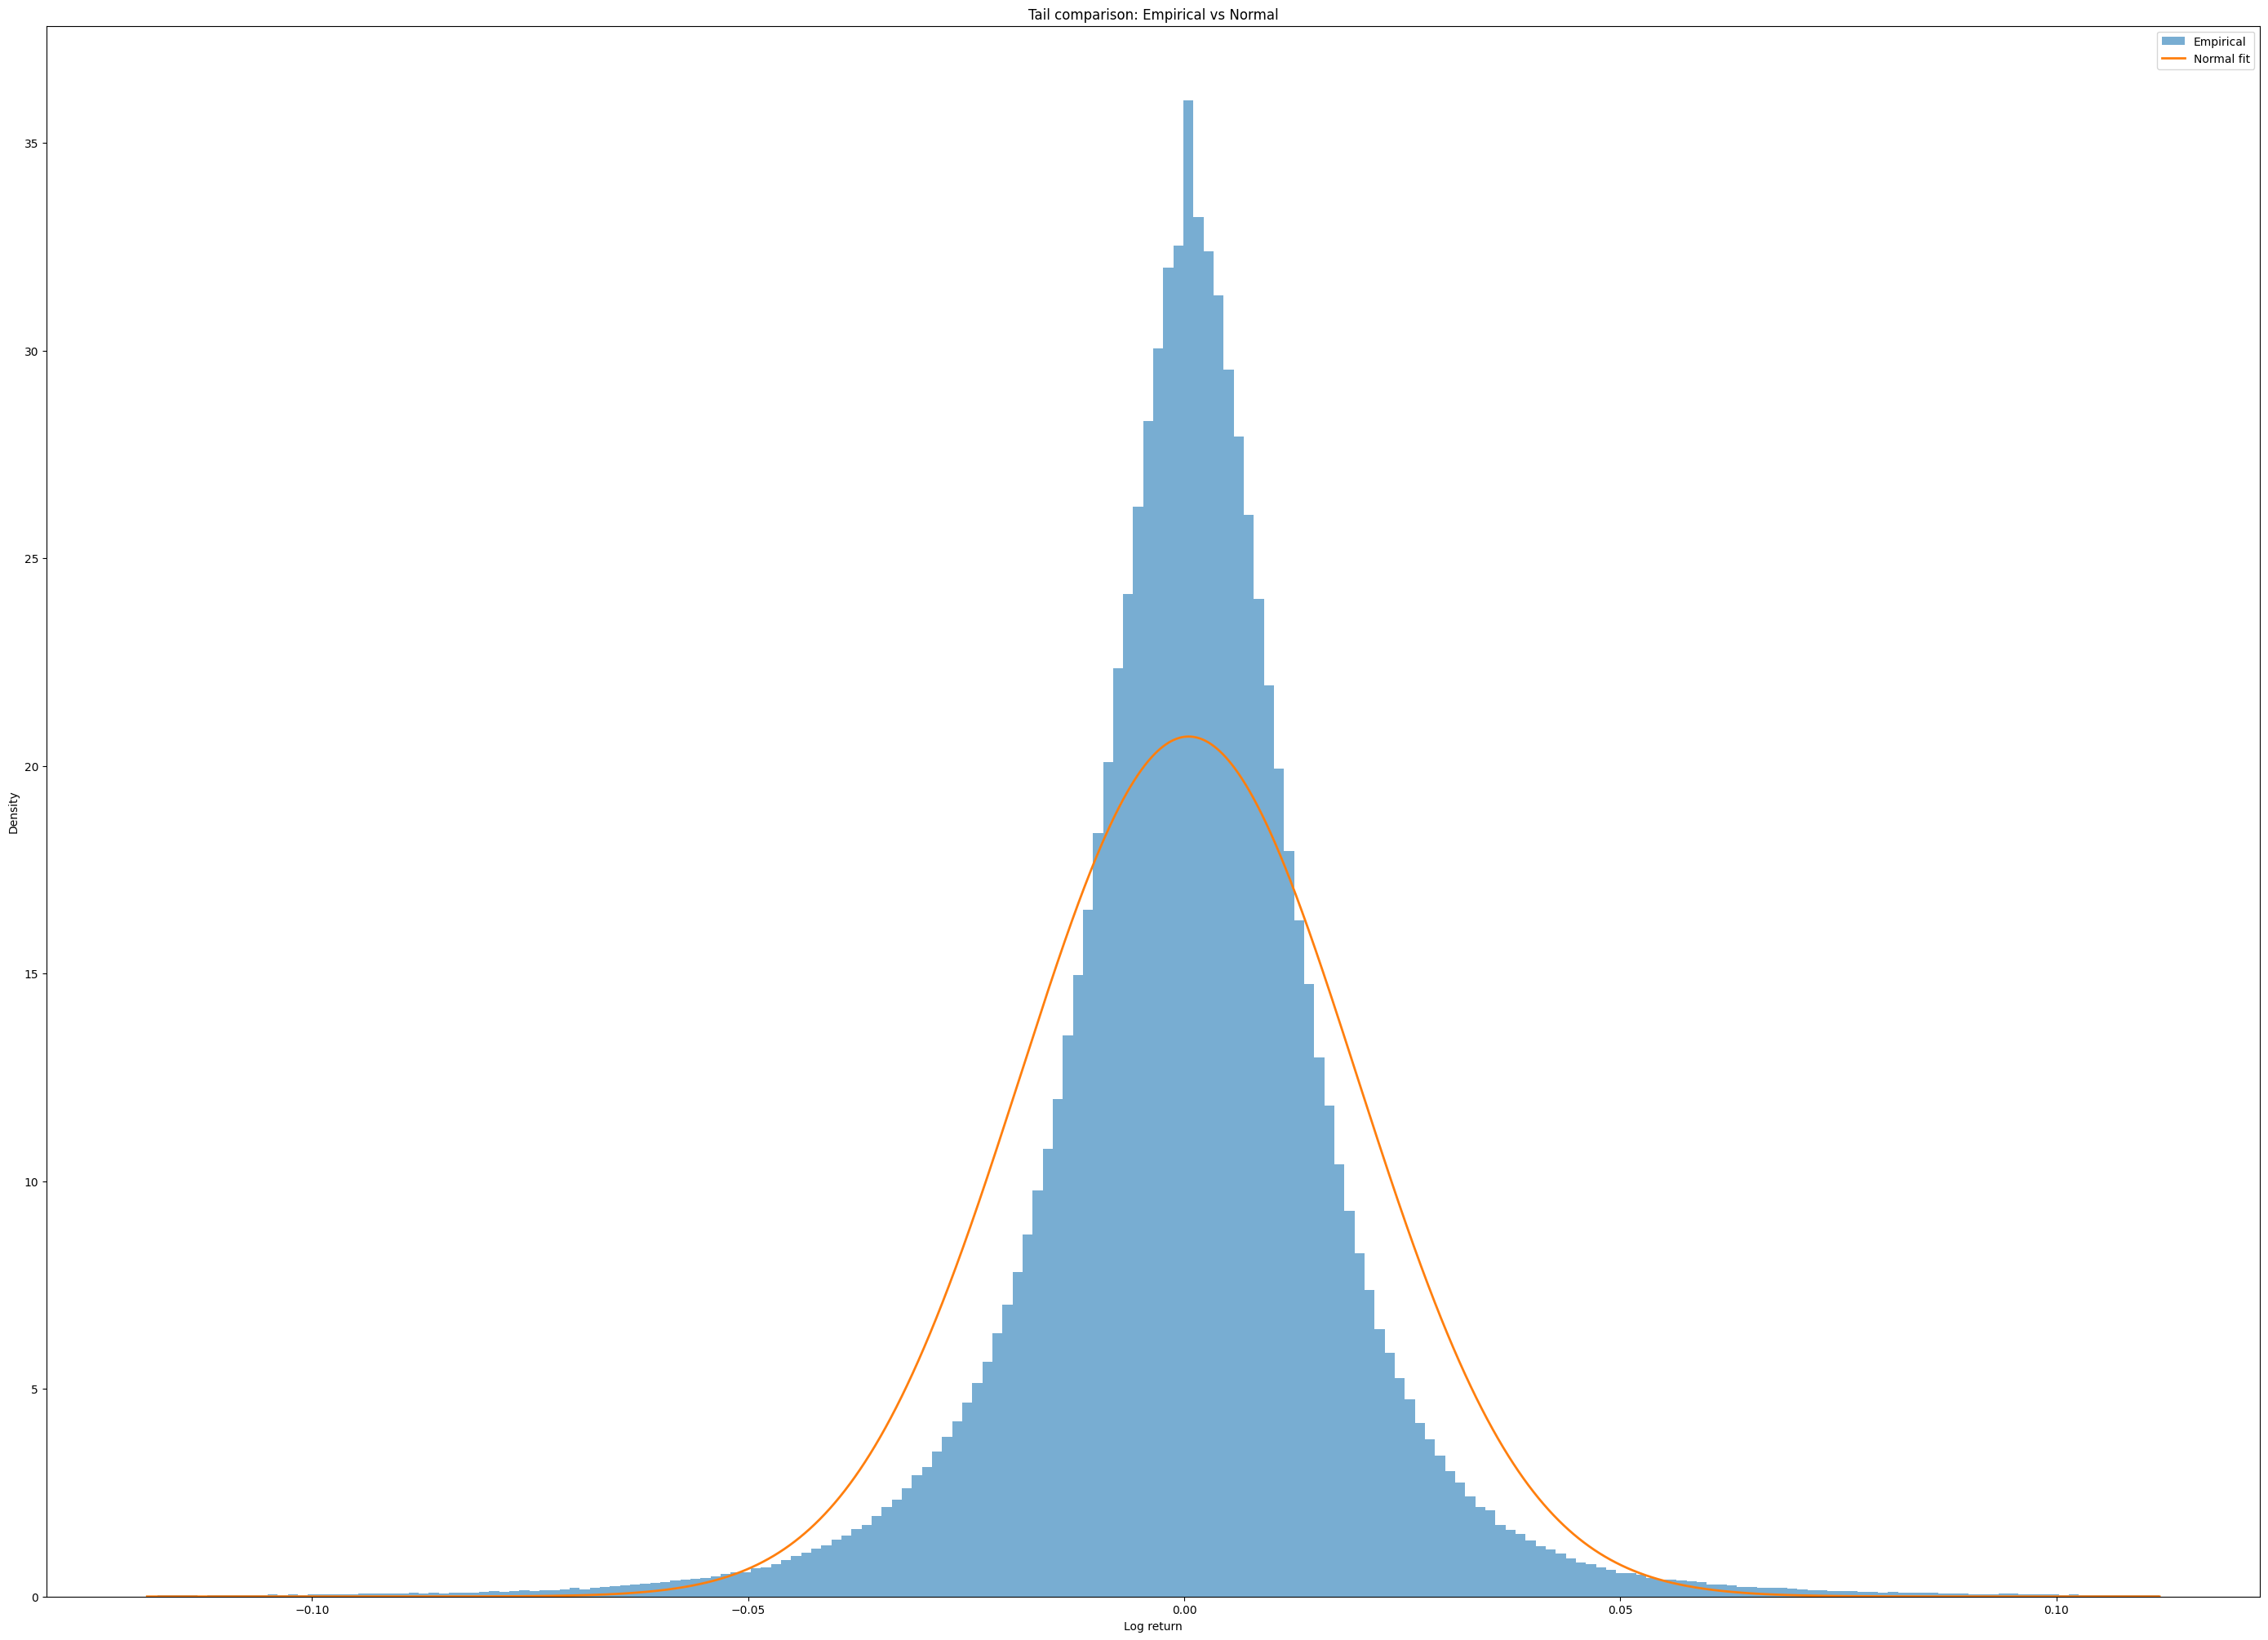

In [49]:
q_low, q_high = returns.quantile([0.001, 0.999])
q_low, q_high

x = np.linspace(q_low, q_high, 10000)
plt.figure(figsize=(35,25))
plt.hist(
    returns,
    bins=200,
    density=True,
    alpha=0.6,
    range=(q_low, q_high),
    label="Empirical"
)

plt.plot(x, norm.pdf(x, mu, sigma), lw=2, label="Normal fit")

plt.xlabel("Log return")
plt.ylabel("Density")
plt.title("Tail comparison: Empirical vs Normal")
plt.legend()

plt.show()

Now I will quantify the fat tails. First with Jarque-Bera and then with a simple ration of the empirical distribution over the normal.

In [50]:
from scipy.stats import jarque_bera

log_returns = df["log_return"].dropna()

jb_stat, jb_p = jarque_bera(log_returns)

print(f"JB statistic: {jb_stat:.2f}")
print(f"p-value: {jb_p:.2e}")


JB statistic: 56921980.14
p-value: 0.00e+00


In [51]:

q_emp = np.quantile(log_returns, [0.01, 0.05, 0.95, 0.99])
mu, sigma = log_returns.mean(), log_returns.std()

q_norm = norm.ppf([0.01, 0.05, 0.95, 0.99], mu, sigma)

tail_df = pd.DataFrame({
    "Empirical": q_emp,
    "Normal": q_norm,
    "Ratio": q_emp / q_norm
}, index=["1%", "5%", "95%", "99%"])

tail_df


,Empirical,Normal,Ratio
1%,-0.053100,-0.044317,1.198182
5%,-0.027515,-0.031187,0.882267
95%,0.027437,0.032195,0.852218
99%,0.051783,0.045325,1.142484


Now, I already did a skewness test (which is negative so leaning on the right with long tail on left) but I would like to now how the two tails differ.

In [52]:
# I try with the 1 percentile
q_low  = np.quantile(log_returns, 0.01)
q_high = np.quantile(log_returns, 0.99)

abs_ratio = abs(q_low) / abs(q_high)

print(q_low, q_high, abs_ratio)


-0.053099826828437384 0.051782701380834 1.025435626425061


ratio ≈ 1 → symmetric tails

ratio > 1 → left tail heavier

ratio < 1 → right tail heavier


In [53]:
# more systematic

levels = [0.001, 0.005, 0.01, 0.05]

tail_asym = []

for p in levels:
    q_l = np.quantile(log_returns, p)
    q_u = np.quantile(log_returns, 1 - p)
    tail_asym.append({
        "p": p,
        "left": q_l,
        "right": q_u,
        "abs_ratio": abs(q_l) / abs(q_u)
    })

pd.DataFrame(tail_asym)


,p,left,right,abs_ratio
0,0.001,-0.118928,0.111830,1.063474
1,0.005,-0.067951,0.066211,1.026276
2,0.010,-0.053100,0.051783,1.025436
3,0.050,-0.027515,0.027437,1.002857


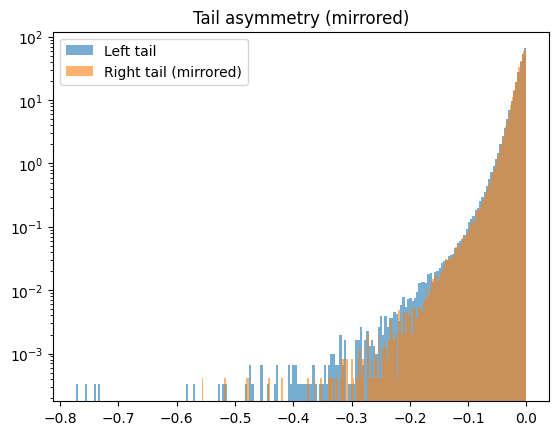

In [54]:
plt.hist(log_returns[log_returns < 0], bins=200, density=True, alpha=0.6, label="Left tail")
plt.hist(-log_returns[log_returns > 0], bins=200, density=True, alpha=0.6, label="Right tail (mirrored)")
plt.yscale("log")
plt.legend()
plt.title("Tail asymmetry (mirrored)")
plt.show()


Btw, the graph is in density mode, that's why it goes down to 10-3.

Now, I nee to check what are these outliers.

I could make a top 10 smallest returns and top 10 highest.

In [55]:
worst_10 = (
    df
    .sort_values(by="log_return", ascending=True)
    .head(10)
)

worst_10


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return
1075650,2020-03-09,APA,13.420000,13.700000,9.320000,9.550000,8.302564,28073200.0,17.996134,-0.538647,-53.864737,-0.773593
1508391,2024-04-11,GL,98.480003,98.580002,38.950001,49.169998,48.506897,36577500.0,103.514908,-0.531402,-53.140182,-0.758010
954534,2019-01-14,PCG,9.210000,9.730000,7.780000,8.380000,8.309790,127198800.0,17.442627,-0.523593,-52.359300,-0.741483
1075911,2020-03-09,OXY,15.580000,19.190001,12.040000,12.510000,11.763835,104930300.0,24.515041,-0.520138,-52.013807,-0.734257
1671761,2025-10-29,FISV,71.360001,76.650002,66.580002,70.599998,70.599998,103454200.0,126.169998,-0.440438,-44.043751,-0.580600
461946,2014-05-16,TKO,10.550000,11.930000,10.550000,11.270000,9.231175,40965100.0,16.324518,-0.434521,-43.452080,-0.570082
926019,2018-10-04,SMCI,1.516000,1.516000,0.850000,1.260000,1.260000,125601000.0,2.140000,-0.411215,-41.121499,-0.529694
1539005,2024-07-26,DXCM,66.000000,67.440002,62.340000,64.000000,64.000000,53914100.0,107.849998,-0.406583,-40.658321,-0.521858
1636825,2025-07-02,CNC,37.340000,37.779999,33.759998,33.779999,33.779999,93566700.0,56.650002,-0.403707,-40.370701,-0.517023
1597251,2025-02-13,WST,243.839996,249.410004,197.009995,199.110001,198.591354,5219500.0,321.440521,-0.382183,-38.218320,-0.481563


In [56]:
best_10 = (
    df
    .sort_values(by="log_return", ascending=False)
    .head(10)
)

best_10


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return
957474,2019-01-24,PCG,7.900000,14.500000,7.300000,13.950000,13.833123,8.253830e+07,7.923057,0.745933,74.593265,0.557289
556975,2015-04-13,BLDR,11.000000,11.740000,10.500000,11.570000,11.570000,1.737750e+07,6.900000,0.676812,67.681153,0.516894
348155,2013-04-19,VRTX,81.550003,85.900002,80.099998,85.599998,85.599998,2.489500e+07,52.869999,0.619066,61.906564,0.481849
687233,2016-07-05,DHR,68.634750,71.276596,68.563828,71.276596,68.012505,1.764880e+07,42.186550,0.612185,61.218456,0.477590
248195,2012-05-07,VRTX,52.119999,58.750000,51.849998,58.119999,58.119999,4.021630e+07,37.410000,0.553595,55.359527,0.440572
666142,2016-04-22,AMD,3.190000,3.990000,3.180000,3.990000,3.990000,1.432653e+08,2.620000,0.522901,52.290083,0.420617
344564,2013-04-09,FSLR,27.139999,41.000000,26.760000,39.349998,39.349998,4.017120e+07,27.040001,0.455251,45.525137,0.375179
1146231,2020-11-04,BIIB,253.199997,363.920013,251.750000,355.630005,355.630005,1.459150e+07,247.009995,0.439739,43.973933,0.364462
323253,2013-01-24,NFLX,2.057000,2.131000,1.994571,2.098000,2.098000,1.188054e+09,1.475143,0.422235,42.223507,0.352230
472895,2014-06-24,VRTX,98.019997,98.800003,89.930000,93.529999,93.529999,2.523680e+07,66.610001,0.404143,40.414349,0.339428


In [57]:
outliers = pd.concat(
    {
        "Worst returns": worst_10,
        "Best returns": best_10
    }
)

outliers


Date Ticker        Open        High         Low  \
Worst returns 1075650 2020-03-09    APA   13.420000   13.700000    9.320000   
              1508391 2024-04-11     GL   98.480003   98.580002   38.950001   
              954534  2019-01-14    PCG    9.210000    9.730000    7.780000   
              1075911 2020-03-09    OXY   15.580000   19.190001   12.040000   
              1671761 2025-10-29   FISV   71.360001   76.650002   66.580002   
              461946  2014-05-16    TKO   10.550000   11.930000   10.550000   
              926019  2018-10-04   SMCI    1.516000    1.516000    0.850000   
              1539005 2024-07-26   DXCM   66.000000   67.440002   62.340000   
              1636825 2025-07-02    CNC   37.340000   37.779999   33.759998   
              1597251 2025-02-13    WST  243.839996  249.410004  197.009995   
Best returns  957474  2019-01-24    PCG    7.900000   14.500000    7.300000   
              556975  2015-04-13   BLDR   11.000000   11.740000   10.500000   
              348155  2013-04-19   VRTX   81.550003   85.900002   80.099998   
              687233  2016-07-05    DHR   68.634750   71.276596   68.563828   
              248195  2012-05-07   VRTX   52.119999   58.750000   51.849998   
              666142  2016-04-22    AMD    3.190000    3.990000    3.180000   
              344564  2013-04-09   FSLR   27.139999   41.000000   26.760000   
              1146231 2020-11-04   BIIB  253.199997  363.920013  251.750000   
              323253  2013-01-24   NFLX    2.057000    2.131000    1.994571   
              472895  2014-06-24   VRTX   98.019997   98.800003   89.930000   

                            Close   Adj Close        Volume  \
Worst returns 1075650    9.550000    8.302564  2.807320e+07   
              1508391   49.169998   48.506897  3.657750e+07   
              954534     8.380000    8.309790  1.271988e+08   
              1075911   12.510000   11.763835  1.049303e+08   
              1671761   70.599998   70.599998  1.034542e+08   
              461946    11.270000    9.231175  4.096510e+07   
              926019     1.260000    1.260000  1.256010e+08   
              1539005   64.000000   64.000000  5.391410e+07   
              1636825   33.779999   33.779999  9.356670e+07   
              1597251  199.110001  198.591354  5.219500e+06   
Best returns  957474    13.950000   13.833123  8.253830e+07   
              556975    11.570000   11.570000  1.737750e+07   
              348155    85.599998   85.599998  2.489500e+07   
              687233    71.276596   68.012505  1.764880e+07   
              248195    58.119999   58.119999  4.021630e+07   
              666142     3.990000    3.990000  1.432653e+08   
              344564    39.349998   39.349998  4.017120e+07   
              1146231  355.630005  355.630005  1.459150e+07   
              323253     2.098000    2.098000  1.188054e+09   
              472895    93.529999   93.529999  2.523680e+07   

                       previous_adj_close  arithmetic_return  \
Worst returns 1075650           17.996134          -0.538647   
              1508391          103.514908          -0.531402   
              954534            17.442627          -0.523593   
              1075911           24.515041          -0.520138   
              1671761          126.169998          -0.440438   
              461946            16.324518          -0.434521   
              926019             2.140000          -0.411215   
              1539005          107.849998          -0.406583   
              1636825           56.650002          -0.403707   
              1597251          321.440521          -0.382183   
Best returns  957474             7.923057           0.745933   
              556975             6.900000           0.676812   
              348155            52.869999           0.619066   
              687233            42.186550           0.612185   
              248195            37.410000           0.553595   
              666142

I need to account for corporate actions.